# ■ 딥러닝 컴페티션

### 컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## ■ 깃허브 정리 (10점)

1. 포트폴리오로 쓸 수 있도록 프로젝트 제목, 전처리, EDA, 모델링 방법, 성능 결과를 캡처 이미지와 함께 잘 정리.

</br>

## ■ 제출방법

5월 12일 23시 59분까지, 오승환 강사에게 DM으로 ipynb 파일 제출, 이후 깃허브 링크도 정리되는대로 DM 제출

# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

file_path = 'train2.csv'
data = pd.read_csv(file_path)

data = data.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])

categorical_columns = ['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

target_encoder = LabelEncoder()
data['Credit_Score'] = target_encoder.fit_transform(data['Credit_Score'])

X = data.drop('Credit_Score', axis=1).values
y = data['Credit_Score'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class CreditScoreDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = CreditScoreDataset(X_train, y_train)
test_dataset = CreditScoreDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


input_size = X_train.shape[1]
model = MLP(input_size).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    model.eval()
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()

    train_accuracy = 100 * correct_train / total_train
    val_accuracy = 100 * correct_val / total_val
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
          f'학습 정확도: {train_accuracy:.2f}%, 평가 정확도: {val_accuracy:.2f}%')


Epoch [1/20], Loss: 0.6904, 학습 정확도: 68.20%, 평가 정확도: 69.81%
Epoch [2/20], Loss: 0.6520, 학습 정확도: 70.43%, 평가 정확도: 70.04%
Epoch [3/20], Loss: 0.6422, 학습 정확도: 70.70%, 평가 정확도: 70.48%
Epoch [4/20], Loss: 0.6365, 학습 정확도: 70.90%, 평가 정확도: 70.59%
Epoch [5/20], Loss: 0.6313, 학습 정확도: 71.17%, 평가 정확도: 70.56%
Epoch [6/20], Loss: 0.6271, 학습 정확도: 71.31%, 평가 정확도: 70.59%
Epoch [7/20], Loss: 0.6233, 학습 정확도: 71.52%, 평가 정확도: 70.71%
Epoch [8/20], Loss: 0.6203, 학습 정확도: 71.63%, 평가 정확도: 71.14%
Epoch [9/20], Loss: 0.6174, 학습 정확도: 71.77%, 평가 정확도: 70.50%
Epoch [10/20], Loss: 0.6149, 학습 정확도: 72.03%, 평가 정확도: 70.88%
Epoch [11/20], Loss: 0.6129, 학습 정확도: 72.06%, 평가 정확도: 71.20%
Epoch [12/20], Loss: 0.6106, 학습 정확도: 72.13%, 평가 정확도: 71.27%
Epoch [13/20], Loss: 0.6076, 학습 정확도: 72.28%, 평가 정확도: 71.20%
Epoch [14/20], Loss: 0.6058, 학습 정확도: 72.40%, 평가 정확도: 71.61%
Epoch [15/20], Loss: 0.6039, 학습 정확도: 72.46%, 평가 정확도: 71.54%
Epoch [16/20], Loss: 0.6016, 학습 정확도: 72.55%, 평가 정확도: 71.79%
Epoch [17/20], Loss: 0.5995, 학습 정확도: 72.81%, 평가 정

In [ ]:
# 이 MLP baseline은 초기 성능 확인용 단순 기준 모델이다.
# 이 코드에서는 전체 데이터에 StandardScaler를 먼저 적용한 뒤 train/test split을 수행하므로,
# 엄밀히는 validation 데이터 정보가 scaler에 일부 반영될 수 있다.
# 이후 최종 TabTransformer 실험에서는 train/valid split 이후 train 데이터 기준으로만 scaler를 fit하여
# 데이터 누수를 방지하였다.

# 전처리 아이디어 적합성 + 논리

In [3]:
# 초기 MLP 모델은 범주형 변수를 LabelEncoder로 단순 수치화하여 사용하였다.

# 그러나 EDA 결과, pandas 기준 일반 결측치는 없었지만 Type_of_Loan 컬럼에 No Data와 같은 문자열 형태의 숨은 결측 표현이 존재하였다.

# 또한 Type_of_Loan은 고유값이 6,261개로 매우 많아 단순 수치 인코딩보다 범주형 embedding 방식이 더 적합하다고 판단하였다.

#  따라서 ID, Customer_ID, Name, SSN과 같은 식별자 컬럼은 제거하고,

#  Type_of_Loan과 Payment_Behaviour는 원본 범주형 변수로 유지하였다.

#  수치형 변수는 스케일링을 적용하고, 이후 금융적 의미를 반영한 비율형 파생변수를 추가하여 모델 입력 정보를 강화하고자 하였다.

In [4]:
# 1. 전처리 방향 설정을 위한 기본 확인


import pandas as pd
import numpy as np

file_path = "train2.csv"
df = pd.read_csv(file_path)

print("데이터 shape:", df.shape)
display(df.head())

# 일반 결측치 확인
missing_df = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_ratio(%)": df.isna().mean().mul(100).round(2)
})

display(missing_df)

print("전체 결측치 수:", df.isna().sum().sum())

데이터 shape: (100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,26.822620,265,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.944960,266,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629163,Good
2,5636,3392,3,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,28.609352,267,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.377862,268,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,269,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


,missing_count,missing_ratio(%)
ID,0,0.0
Customer_ID,0,0.0
Month,0,0.0
Name,0,0.0
Age,0,0.0
SSN,0,0.0
Occupation,0,0.0
Annual_Income,0,0.0
Monthly_Inhand_Salary,0,0.0
Num_Bank_Accounts,0,0.0


전체 결측치 수: 0


In [5]:
# 2. 문자열 컬럼 내부의 숨은 결측 표현 확인


object_cols = df.select_dtypes(include="object").columns.tolist()

for col in object_cols:
    print("=" * 80)
    print(f"[{col}] 고유값 개수:", df[col].nunique())
    display(df[col].value_counts(dropna=False).head(20))

[Name] 고유값 개수: 10128


,count
Name,
Stevex,48
Langep,48
Jessicad,48
Nicko,40
Johnc,40
Jessica Wohlt,40
Deepa Seetharamanm,40
Nate Raymondw,40
Raymondr,40


[Occupation] 고유값 개수: 15


,count
Occupation,
Lawyer,7096
Engineer,6864
Architect,6824
Mechanic,6776
Accountant,6744
Scientist,6744
Media_Manager,6720
Developer,6720
Teacher,6672


[Type_of_Loan] 고유값 개수: 6261


...

,count
Payment_of_Min_Amount,
Yes,52326
No,35667
NM,12007


[Payment_Behaviour] 고유값 개수: 6


,count
Payment_Behaviour,
Low_spent_Small_value_payments,28585
High_spent_Medium_value_payments,18851
High_spent_Large_value_payments,14778
Low_spent_Medium_value_payments,14634
High_spent_Small_value_payments,12105
Low_spent_Large_value_payments,11047


[Credit_Score] 고유값 개수: 3


,count
Credit_Score,
Standard,53174
Poor,28998
Good,17828


In [6]:
# 3. Type_of_Loan의 No Data 비율 및 타깃 분포 확인


loan_col = "Type_of_Loan"
target_col = "Credit_Score"

df["loan_group"] = np.where(
    df[loan_col].astype(str).str.strip().eq("No Data"),
    "No Data",
    "Loan Data Exists"
)

print("Type_of_Loan 그룹 개수")
display(df["loan_group"].value_counts())

print("Type_of_Loan 그룹 비율")
display(df["loan_group"].value_counts(normalize=True).mul(100).round(2))

loan_target_ratio = pd.crosstab(
    df["loan_group"],
    df[target_col],
    normalize="index"
).mul(100)

display(loan_target_ratio.round(2))

Type_of_Loan 그룹 개수


,count
loan_group,
Loan Data Exists,88592
No Data,11408


Type_of_Loan 그룹 비율


,proportion
loan_group,
Loan Data Exists,88.59
No Data,11.41


Credit_Score,Good,Poor,Standard
loan_group,,,
Loan Data Exists,16.24,31.22,52.54
No Data,30.19,11.71,58.10


In [7]:
# 4. 식별자 컬럼 확인

id_cols = ["ID", "Customer_ID", "Name", "SSN"]

for col in id_cols:
    print("=" * 80)
    print(col)
    print("고유값 개수:", df[col].nunique())
    print("전체 행 대비 고유값 비율:", round(df[col].nunique() / len(df), 4))
    display(df[col].head())

ID
고유값 개수: 100000
전체 행 대비 고유값 비율: 1.0


,ID
0,5634
1,5635
2,5636
3,5637
4,5638


Customer_ID
고유값 개수: 12500
전체 행 대비 고유값 비율: 0.125


,Customer_ID
0,3392
1,3392
2,3392
3,3392
4,3392


Name
고유값 개수: 10128
전체 행 대비 고유값 비율: 0.1013


,Name
0,Aaron Maashoh
1,Aaron Maashoh
2,Aaron Maashoh
3,Aaron Maashoh
4,Aaron Maashoh


SSN
고유값 개수: 12500
전체 행 대비 고유값 비율: 0.125


,SSN
0,821000265
1,821000265
2,821000265
3,821000265
4,821000265


# EDA를 통한 타당한 해석

,count,ratio(%)
Credit_Score,,
Standard,53174,53.17
Poor,28998,29.00
Good,17828,17.83


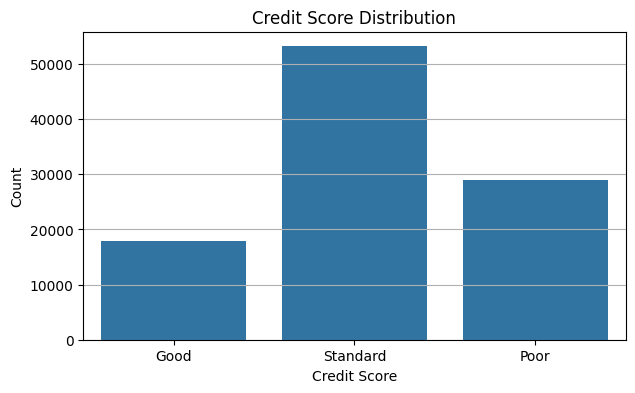

In [8]:
# 1. Target 분포 확인


import matplotlib.pyplot as plt
import seaborn as sns


target_col = "Credit_Score"

target_summary = pd.DataFrame({
    "count": df[target_col].value_counts(),
    "ratio(%)": df[target_col].value_counts(normalize=True).mul(100).round(2)
})

display(target_summary)

plt.figure(figsize=(7, 4))
sns.countplot(
    data=df,
    x=target_col,
    order=["Good", "Standard", "Poor"]
)
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.grid(axis="y")
plt.show()

In [9]:
# Credit_Score는 Standard 비중이 가장 높고, Good 비중이 가장 낮다.
# 따라서 단순 accuracy만 보면 다수 클래스 중심 예측으로 치우칠 수 있으므로,
# # class weight 또는 macro F1 확인이 필요하다.

In [10]:
# 2. 범주형 변수 고유값 개수 확인


categorical_cols = [
    "Month",
    "Occupation",
    "Type_of_Loan",
    "Credit_Mix",
    "Payment_of_Min_Amount",
    "Payment_Behaviour"
]

cat_summary = pd.DataFrame({
    "column": categorical_cols,
    "nunique": [df[col].nunique() for col in categorical_cols]
}).sort_values("nunique", ascending=False)

display(cat_summary)

,column,nunique
2,Type_of_Loan,6261
1,Occupation,15
0,Month,8
5,Payment_Behaviour,6
3,Credit_Mix,3
4,Payment_of_Min_Amount,3


In [11]:
# Type_of_Loan은 고유값이 매우 많은 복합 범주형 변수이다.
# 따라서 단순 LabelEncoding보다 embedding 기반 처리가 더 적합하다고 판단했.

Credit_Mix


Credit_Score,Good,Poor,Standard
Credit_Mix,,,
Bad,1.48,60.12,38.40
Good,48.87,15.97,35.17
Standard,5.73,21.50,72.76


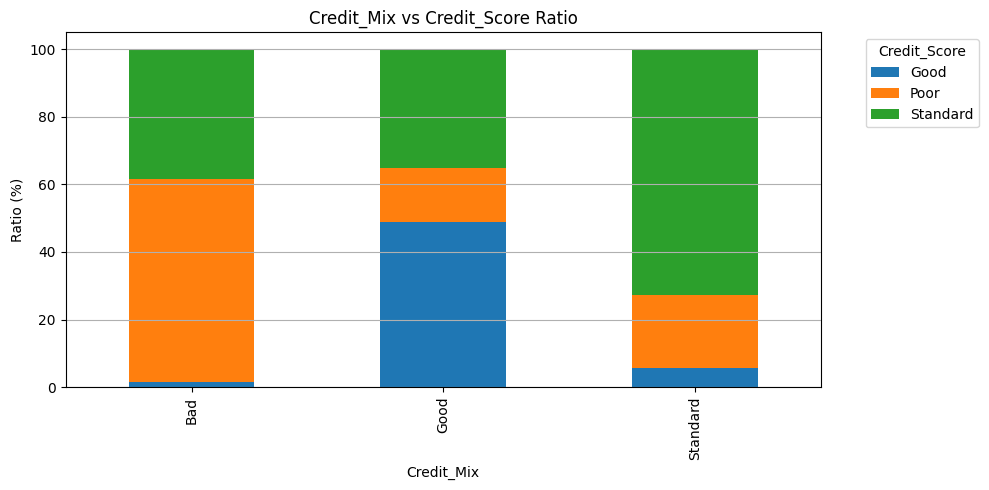

Payment_of_Min_Amount


Credit_Score,Good,Poor,Standard
Payment_of_Min_Amount,,,
NM,18.70,29.30,52.00
No,38.33,13.38,48.29
Yes,3.65,39.57,56.77


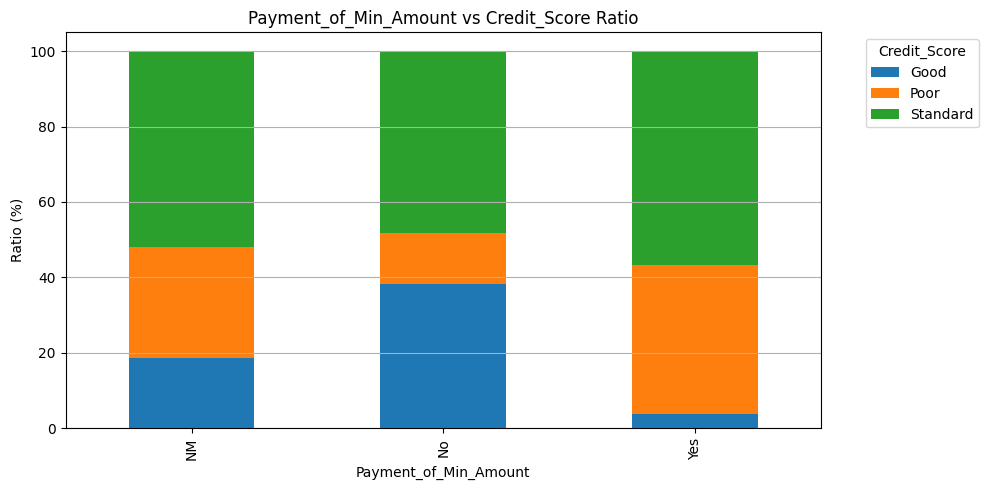

Payment_Behaviour


Credit_Score,Good,Poor,Standard
Payment_Behaviour,,,
High_spent_Large_value_payments,23.32,21.53,55.15
High_spent_Medium_value_payments,20.05,25.55,54.40
High_spent_Small_value_payments,18.64,27.33,54.04
Low_spent_Large_value_payments,17.96,28.23,53.81
Low_spent_Medium_value_payments,18.23,30.07,51.70
Low_spent_Small_value_payments,12.92,35.59,51.49


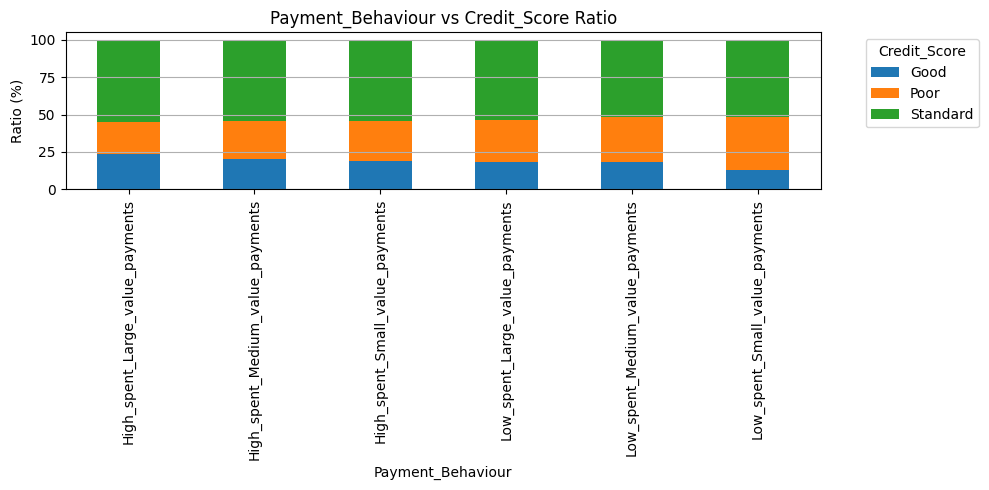

Occupation


Credit_Score,Good,Poor,Standard
Occupation,,,
Accountant,17.87,30.20,51.93
Architect,18.07,27.18,54.75
Developer,18.01,28.63,53.36
Doctor,17.72,27.47,54.81
Engineer,18.41,30.51,51.08
Entrepreneur,17.82,30.58,51.59
Journalist,19.19,28.15,52.66
Lawyer,17.74,27.69,54.57
Manager,18.50,28.86,52.64


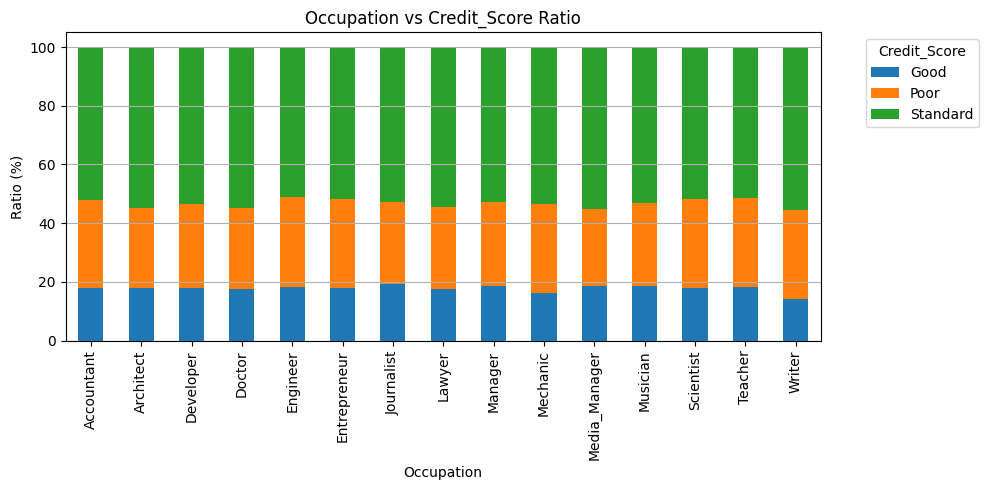

In [12]:
# 3. 범주형 변수별 Credit_Score 비율 확인

def plot_cat_target_ratio(data, col, target_col="Credit_Score"):
    ratio = pd.crosstab(
        data[col],
        data[target_col],
        normalize="index"
    ).mul(100)

    display(ratio.round(2))

    ratio.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5)
    )

    plt.title(f"{col} vs Credit_Score Ratio")
    plt.xlabel(col)
    plt.ylabel("Ratio (%)")
    plt.legend(title=target_col, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


for col in ["Credit_Mix", "Payment_of_Min_Amount", "Payment_Behaviour", "Occupation"]:
    print("=" * 80)
    print(col)
    plot_cat_target_ratio(df, col, target_col)

In [13]:
# 4. 수치형 변수의 Credit_Score별 평균/중앙값 비교


numeric_cols = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Credit_History_Age",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

target_mean = df.groupby(target_col)[numeric_cols].mean().T
target_median = df.groupby(target_col)[numeric_cols].median().T

display(target_mean)
display(target_median)

Credit_Score,Good,Poor,Standard
Age,36.402625,31.194565,33.438673
Annual_Income,65203.672105,40584.515325,50987.164840
Monthly_Inhand_Salary,5399.919696,3380.560657,4239.436890
Num_Bank_Accounts,3.440263,6.526726,5.383966
Num_Credit_Card,4.143258,6.625147,5.404427
Interest_Rate,7.662329,20.187116,13.751420
Num_of_Loan,2.202154,4.755742,3.312164
Delay_from_due_date,10.958997,29.728809,19.759431
Num_of_Delayed_Payment,8.564842,15.809883,13.543518
Changed_Credit_Limit,7.249857,11.116281,11.197803


Credit_Score,Good,Poor,Standard
Age,36.000000,31.000000,33.000000
Annual_Income,44927.860000,32064.860000,36824.175000
Monthly_Inhand_Salary,3828.355000,2672.090000,3097.813333
Num_Bank_Accounts,3.000000,7.000000,5.000000
Num_Credit_Card,4.000000,7.000000,5.000000
Interest_Rate,7.000000,21.000000,13.000000
Num_of_Loan,2.000000,5.000000,3.000000
Delay_from_due_date,10.000000,27.000000,18.000000
Num_of_Delayed_Payment,8.000000,17.000000,14.000000
Changed_Credit_Limit,6.720000,9.720000,10.300000


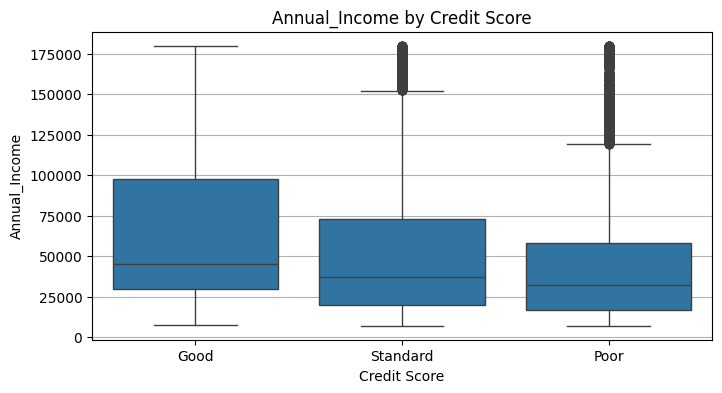

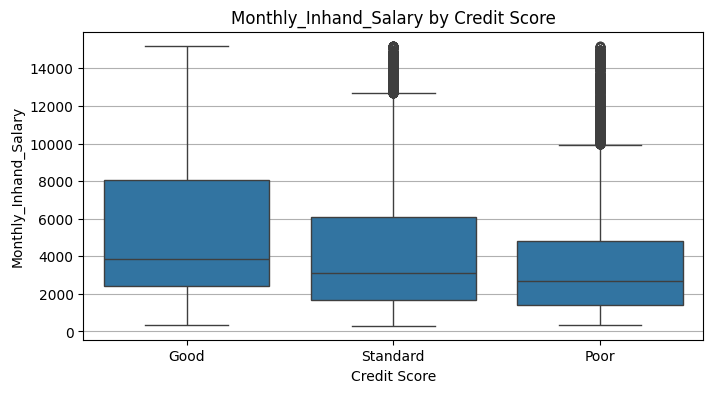

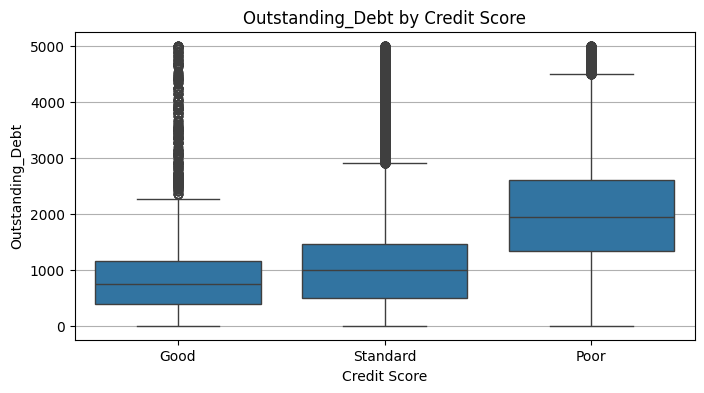

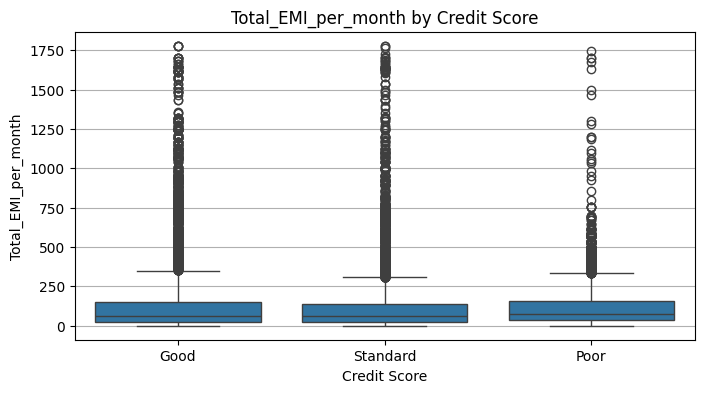

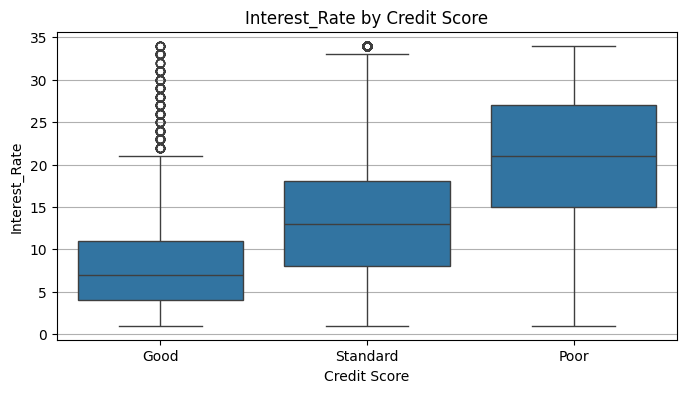

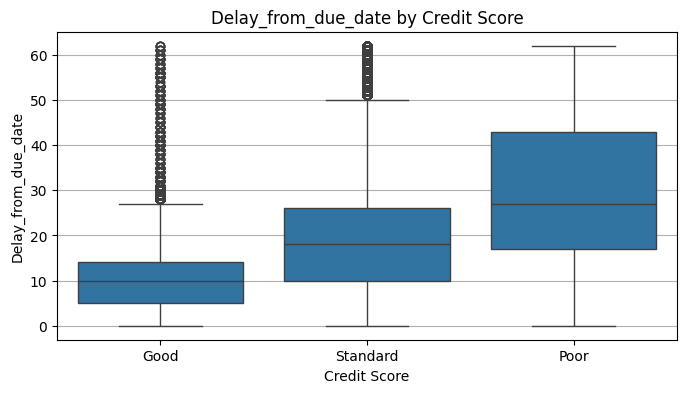

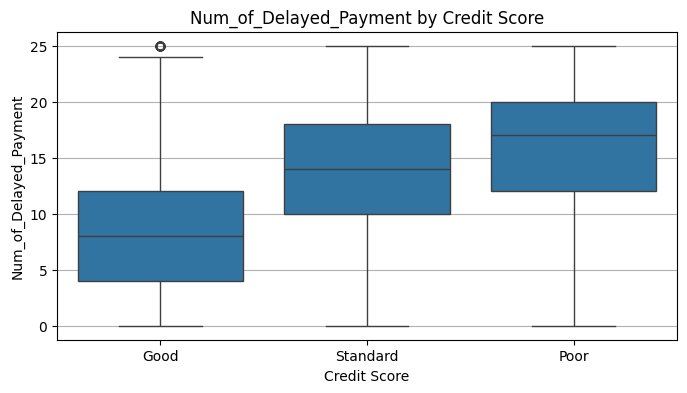

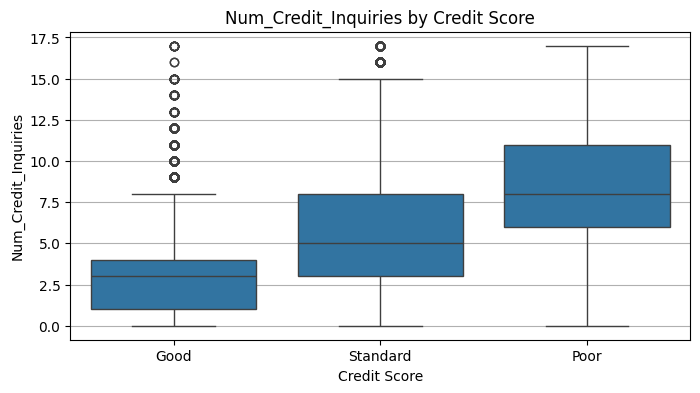

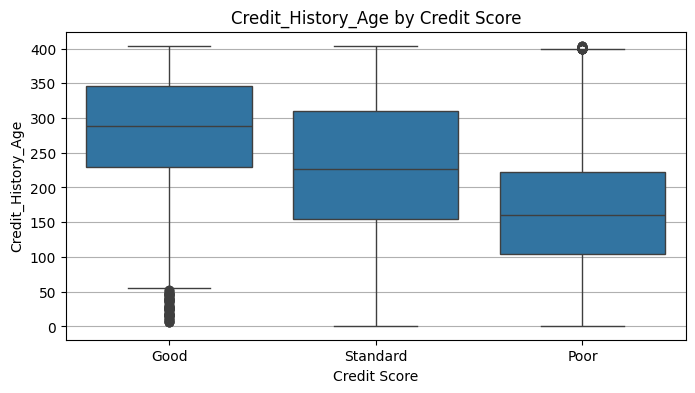

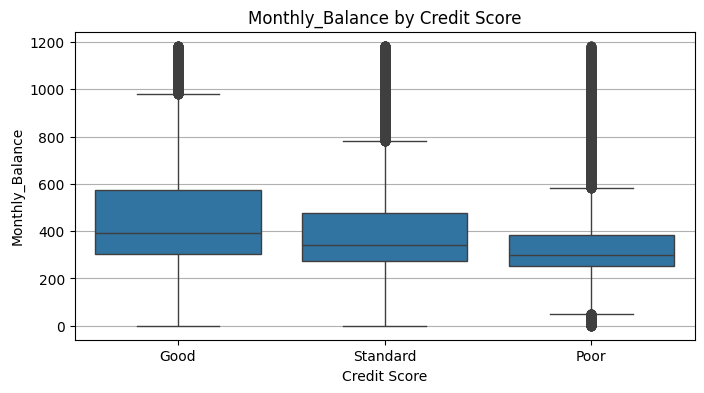

In [14]:
# 5. 주요 수치형 변수 분포 확인


plot_cols = [
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Outstanding_Debt",
    "Total_EMI_per_month",
    "Interest_Rate",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Num_Credit_Inquiries",
    "Credit_History_Age",
    "Monthly_Balance"
]

for col in plot_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(
        data=df,
        x=target_col,
        y=col,
        order=["Good", "Standard", "Poor"]
    )
    plt.title(f"{col} by Credit Score")
    plt.xlabel("Credit Score")
    plt.ylabel(col)
    plt.grid(axis="y")
    plt.show()

In [15]:
# 6. 이상치 및 스케일 차이 확인

numeric_summary = df[numeric_cols].describe().T

numeric_summary["range"] = numeric_summary["max"] - numeric_summary["min"]
numeric_summary["iqr"] = numeric_summary["75%"] - numeric_summary["25%"]
numeric_summary["range_iqr_ratio"] = (
    numeric_summary["range"] / (numeric_summary["iqr"] + 1e-6)
)

display(numeric_summary.sort_values("range_iqr_ratio", ascending=False))

,count,mean,std,min,25%,50%,75%,max,range,iqr,range_iqr_ratio
Total_EMI_per_month,100000.0,107.699208,132.267056,0.000000,29.268886,66.462304,147.392573,1779.103254,1779.103254,118.123687,15.061359
Amount_invested_monthly,100000.0,55.101315,39.006932,0.000000,27.959111,45.156550,71.295797,434.191089,434.191089,43.336686,10.019019
Monthly_Balance,100000.0,392.697586,201.652719,0.007760,267.615983,333.865366,463.215683,1183.930696,1183.922936,195.599700,6.052785
Num_Credit_Card,100000.0,5.533570,2.067098,0.000000,4.000000,5.000000,7.000000,11.000000,11.000000,3.000000,3.666665
Outstanding_Debt,100000.0,1426.220376,1155.129026,0.230000,566.072500,1166.155000,1945.962500,4998.070000,4997.840000,1379.890000,3.621912
Credit_Utilization_Ratio,100000.0,32.285173,5.116875,20.000000,28.052567,32.305784,36.496663,50.000000,30.000000,8.444096,3.552778
Delay_from_due_date,100000.0,21.081410,14.804560,0.000000,10.000000,18.000000,28.000000,62.000000,62.000000,18.000000,3.444444
Monthly_Inhand_Salary,100000.0,4197.270835,3186.432497,303.645417,1626.594167,3095.905000,5957.715000,15204.633330,14900.987913,4331.120833,3.440446
Num_Credit_Inquiries,100000.0,5.798250,3.867826,0.000000,3.000000,5.000000,8.000000,17.000000,17.000000,5.000000,3.399999
Annual_Income,100000.0,50505.123449,38299.422093,7005.930000,19342.972500,36999.705000,71683.470000,179987.280000,172981.350000,52340.497500,3.304924


In [16]:
# 일부 금융 변수는 max-min 범위가 IQR 대비 크게 나타났다.
# 따라서 평균/표준편차 기반 StandardScaler뿐 아니라,
# 중앙값/IQR 기반 RobustScaler를 비교할 필요가 있다.

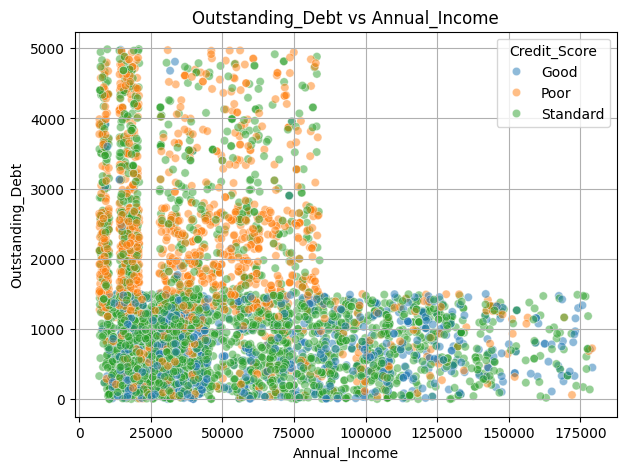

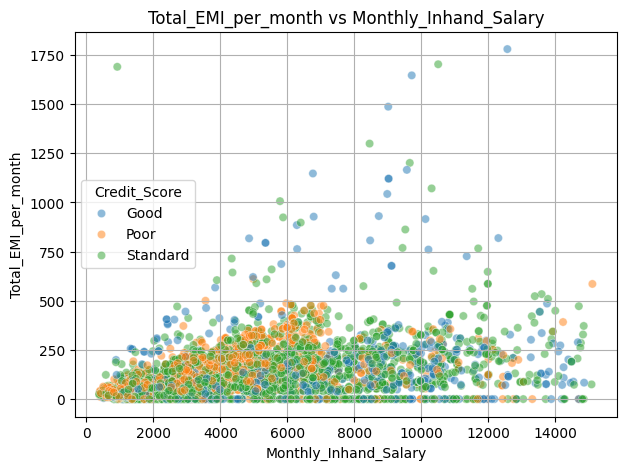

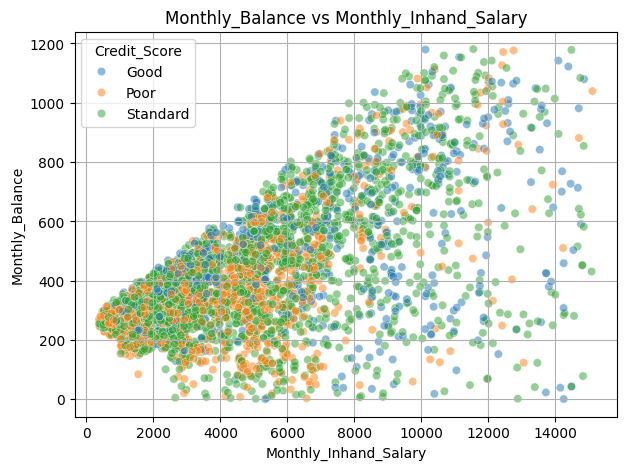

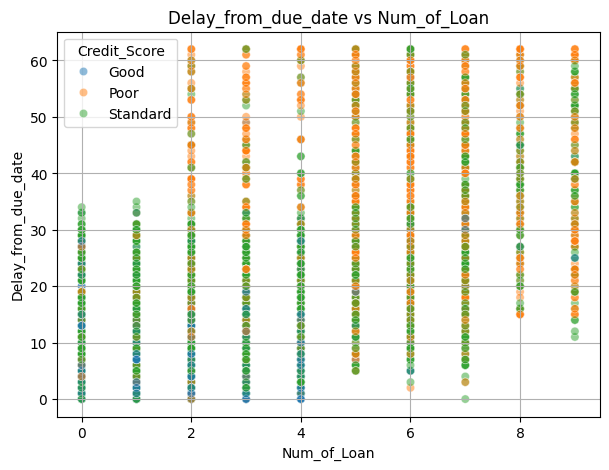

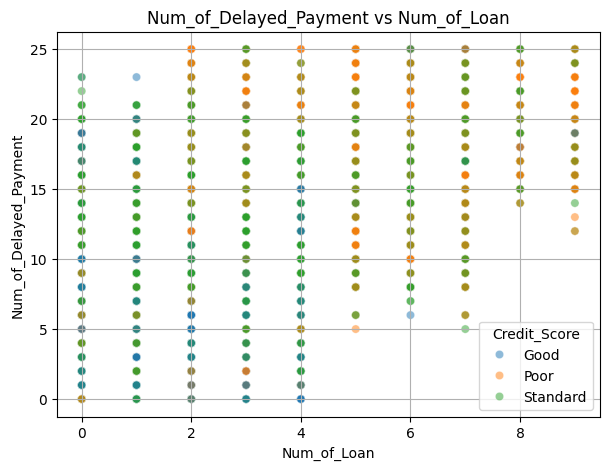

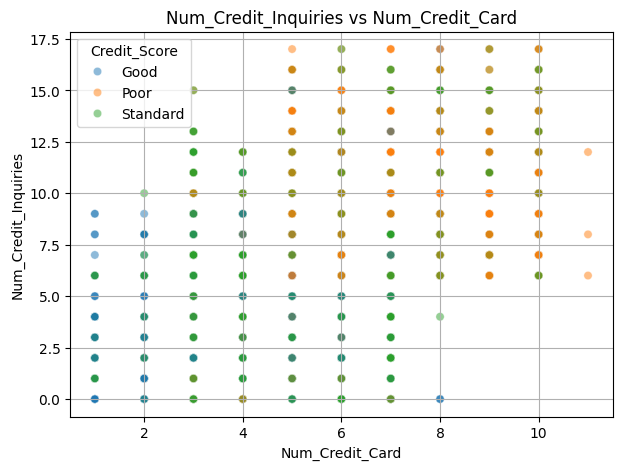

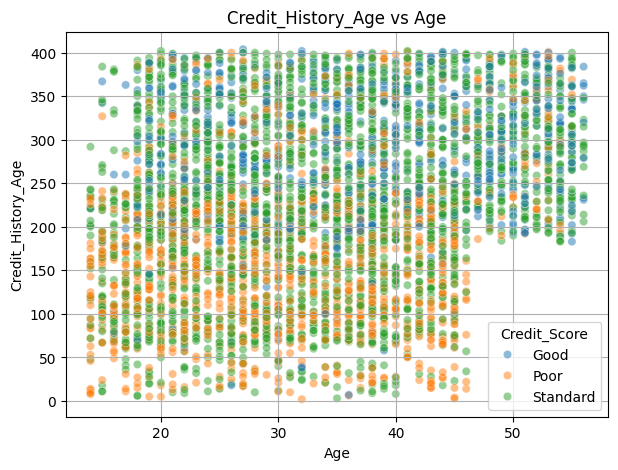

In [17]:
# 7. 파생변수 필요성 확인용 변수 관계 시각화


sample_df = df.sample(5000, random_state=42)

pair_cols = [
    ("Annual_Income", "Outstanding_Debt"),
    ("Monthly_Inhand_Salary", "Total_EMI_per_month"),
    ("Monthly_Inhand_Salary", "Monthly_Balance"),
    ("Num_of_Loan", "Delay_from_due_date"),
    ("Num_of_Loan", "Num_of_Delayed_Payment"),
    ("Num_Credit_Card", "Num_Credit_Inquiries"),
    ("Age", "Credit_History_Age")
]

for x_col, y_col in pair_cols:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=sample_df,
        x=x_col,
        y=y_col,
        hue=target_col,
        alpha=0.5
    )
    plt.title(f"{y_col} vs {x_col}")
    plt.grid(True)
    plt.show()

In [18]:
# 7. 파생변수 필요성 확인용 변수 관계 시각화
# 목적:
# 원본 수치형 변수들은 각각 Credit_Score와 관련이 있지만,
# 단순 절대값만으로는 고객의 실제 금융 부담을 충분히 설명하기 어렵다.

# 예를 들어 Outstanding_Debt가 높더라도 Annual_Income이 충분히 높으면
# 실제 부채 부담은 낮을 수 있고,
# Total_EMI_per_month가 높더라도 Monthly_Inhand_Salary가 높으면
# 상환 부담은 상대적으로 낮을 수 있다.

# 따라서 본 단계에서는 원본 변수 간 관계를 시각화하여
# 소득 대비 부채, 월급 대비 상환액, 대출 건수 대비 연체일 등
# 비율형 파생변수가 필요한지 확인한다.

# 이 과정은 단순히 feature를 추가하는 것이 아니라,
# EDA에서 확인한 금융적 관계를 모델이 더 명확히 학습할 수 있도록
# 원본 변수 간 상대적 의미를 수치화하기 위한 전처리 근거이다.

# Feature Selection과 모델 선택, 튜닝 기준

In [19]:
# EDA 결과 ID, Customer_ID, Name, SSN은 식별자 성격이 강해 모델 입력에서 제외하였다.
# Credit_Mix, Payment_of_Min_Amount, Payment_Behaviour는 Credit_Score별 분포 차이가 뚜렷하여 유지하였다.
# Type_of_Loan은 고유값이 6,261개로 많은 복합 범주형 변수이므로 단순 LabelEncoding보다 embedding 기반 처리가 적합하다고 판단하였다.
# 수치형 변수는 소득, 부채, 금리, 연체, 신용이력 관련 컬럼을 유지하였다.
# 파생변수는 EDA 기반으로 별도 실험하되, 최종 채택 여부는 validation score 비교 결과에 따라 결정하였다.
# 모델은 MLP baseline 이후 TabTransformer를 선택하였고, 튜닝 기준은 Valid Accuracy, Macro F1, class별 recall, train-valid loss gap으로 설정하였다.

In [20]:
target_col = "Credit_Score"

# 식별자 컬럼 제거
drop_cols = [
    "ID",
    "Customer_ID",
    "Name",
    "SSN",
    "loan_group",
    target_col
]

# 주요 범주형 변수 유지
categorical_cols = [
    "Month",
    "Occupation",
    "Type_of_Loan",
    "Credit_Mix",
    "Payment_of_Min_Amount",
    "Payment_Behaviour"
]

# 수치형 변수 자동 선택
numeric_cols = [
    col for col in df.select_dtypes(include=["int64", "float64"]).columns
    if col not in drop_cols
]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)
print("Numeric column count:", len(numeric_cols))

Categorical columns: ['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
Numeric columns: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'loan_group']
Numeric column count: 18


In [21]:
# | 튜닝 항목        | 기준                                         |
# | ---------------- | ---------------------------------------------|
# | Scaler           | StandardScaler vs RobustScaler 비교          |
# | Class weight     | alpha 0.3 / 0.5 / 0.7 비교                   |
# | Epoch            | 80 epoch + early stopping                    |
# | Dropout          | 0.1 / 0.2 비교                               |
# | 파생변수         | 원본 feature vs 파생변수 추가 feature 비교   |
# | 평가 기준        | Valid Accuracy + Macro F1 + 클래스별 recall  |

# 개선사항

In [23]:
# 초기 MLP baseline은 범주형 변수를 LabelEncoding으로 단순 수치화하여 사용했기 때문에,
# Type_of_Loan처럼 고유값이 많고 복잡한 범주형 변수의 구조를 충분히 반영하기 어려웠다.
# 이를 개선하기 위해 범주형 변수를 embedding으로 학습할 수 있는 TabTransformer를 적용하였다.
# 클래스 불균형은 alpha=0.5 기반 class weight로 완화하였다.
# 수치형 변수는 StandardScaler와 RobustScaler를 비교하였고, 파생변수는 EDA 기반으로 선별하여 추가 실험하였다.
# 다만 파생변수와 RobustScaler가 항상 성능 향상으로 이어지지는 않았으므로,
# 최종 모델은 원본 변수 모델과 파생변수 모델의 validation score를 비교한 뒤 가장 높은 설정으로 선택한다.

# 파생변수 선별 기준

In [24]:
# 1차 파생변수 실험에서는 여러 비율형 변수를 추가했지만 원본 모델보다 validation score가 낮게 나타났다.
# 따라서 파생변수를 많이 추가하는 방식보다, EDA에서 Credit_Score별 차이가 뚜렷했던 변수 조합만 선별하였다.
# Poor 집단은 Good 집단보다 부채, 금리, 대출 수, 연체일, 지연납부 횟수, 신용조회 횟수가 높고,
# 소득과 신용이력 기간은 낮게 나타났다.
# 이에 따라 소득 대비 부채, 금리-부채 부담, 연체 심각도, 대출-금리 부담,
# 신용이력 대비 조회 강도 변수를 생성하여 원본 변수만 사용한 모델과 성능을 비교하였다.

# validation score 적절하게 출력

원본 변수만 사용한 TabTransformer 모델

사용 장치: cuda
GPU: Tesla T4
원본 데이터 shape: (100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,26.822620,265,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.944960,266,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629163,Good
2,5636,3392,3,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,28.609352,267,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.377862,268,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,269,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


Categorical columns: ['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
Numeric columns: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']
Numeric column count: 17
Target 분포


,proportion
Credit_Score,
Standard,53.17
Poor,29.00
Good,17.83


train shape: (80000, 29)
valid shape: (20000, 29)

train target ratio


...

Epoch [79/80] Valid:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [79/80] Train Loss: 0.1421 | Valid Loss: 0.7901 | Train Acc: 94.05% | Valid Acc: 83.38% | Valid Macro F1: 0.8305 | EarlyStop: 5/10


Epoch [80/80] Train:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [80/80] Valid:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [80/80] Train Loss: 0.1414 | Valid Loss: 0.7923 | Train Acc: 93.98% | Valid Acc: 83.38% | Valid Macro F1: 0.8298 | EarlyStop: 6/10

Best Valid Acc: 0.83465
Best model saved: best_tabtransformer_original_features.pth


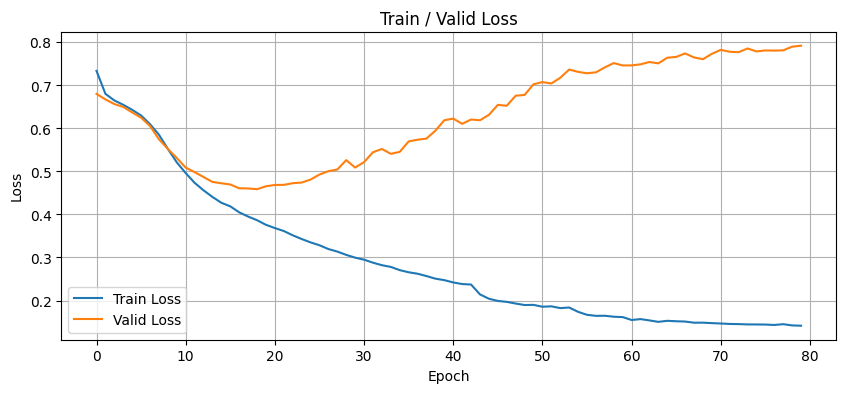

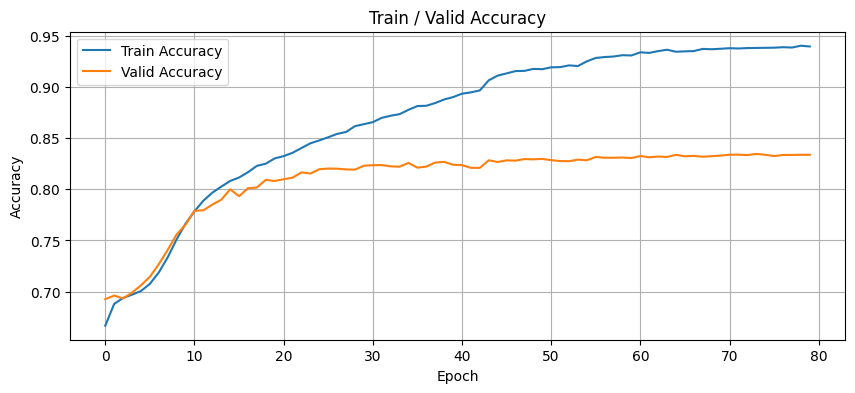

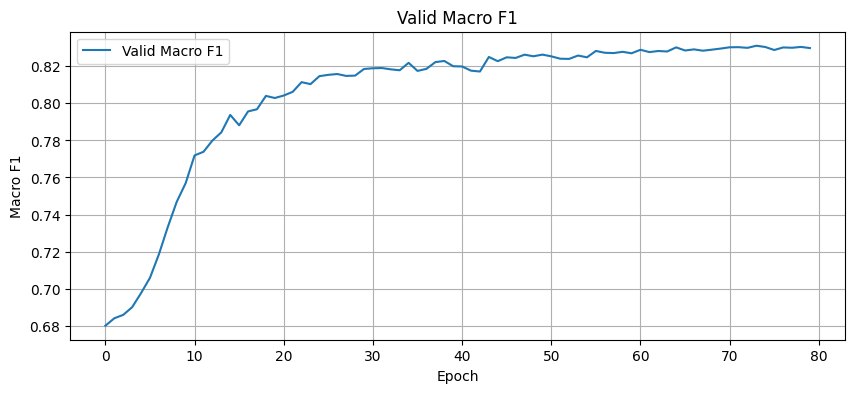

Final Validation Score - Original Features Only
Final Valid Accuracy: 0.83465
Final Valid Macro F1: 0.8311
Final Valid Weighted F1: 0.83505

Classification Report
              precision    recall  f1-score   support

        Good       0.76      0.88      0.82      3566
        Poor       0.81      0.87      0.84      5799
    Standard       0.89      0.80      0.84     10635

    accuracy                           0.83     20000
   macro avg       0.82      0.85      0.83     20000
weighted avg       0.84      0.83      0.84     20000


Confusion Matrix


,Pred_Good,Pred_Poor,Pred_Standard
True_Good,3150,20,396
True_Poor,58,5036,705
True_Standard,946,1182,8507


,Experiment,Scaler,Derived Features,Accuracy,Macro F1,Weighted F1
0,Original Features Only,StandardScaler,None,0.83465,0.831101,0.83505


In [25]:
# Original Feature Only Validation Score Code
# TabTransformer + 원본 변수만 사용 + Class Weight
# 파생변수 없음


import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. Seed / Device
# ============================================================

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 장치:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 2. Data Load
# ============================================================

file_path = "train2.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"{file_path} 파일이 현재 경로에 없습니다.")

df = pd.read_csv(file_path)

print("원본 데이터 shape:", df.shape)
display(df.head())


# ============================================================
# 3. Feature Selection
# ============================================================
# 파생변수 생성 없음
# 원본 컬럼만 사용

target_col = "Credit_Score"

drop_cols = [
    "ID",
    "Customer_ID",
    "Name",
    "SSN",
    target_col
]

categorical_cols = [
    "Month",
    "Occupation",
    "Type_of_Loan",
    "Credit_Mix",
    "Payment_of_Min_Amount",
    "Payment_Behaviour"
]

drop_cols = [col for col in drop_cols if col in df.columns]
categorical_cols = [col for col in categorical_cols if col in df.columns]

numeric_cols = [
    col for col in df.columns
    if col not in drop_cols + categorical_cols
]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)
print("Numeric column count:", len(numeric_cols))


# ============================================================
# 4. Target Encoding
# ============================================================

target_mapping = {
    "Good": 0,
    "Poor": 1,
    "Standard": 2
}

inverse_target_mapping = {
    0: "Good",
    1: "Poor",
    2: "Standard"
}

df["target"] = df[target_col].map(target_mapping)

print("Target 분포")
display(df[target_col].value_counts(normalize=True).mul(100).round(2))


# ============================================================
# 5. Train / Valid Split
# ============================================================

train_df, valid_df = train_test_split(
    df,
    test_size=0.2,
    random_state=seed,
    stratify=df["target"]
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print("train shape:", train_df.shape)
print("valid shape:", valid_df.shape)

print("\ntrain target ratio")
display(train_df[target_col].value_counts(normalize=True).round(3))

print("\nvalid target ratio")
display(valid_df[target_col].value_counts(normalize=True).round(3))


# ============================================================
# 6. Categorical Encoding
# ============================================================
# train 기준 mapping 생성
# valid에서 처음 보는 category는 0번 Unknown 처리

cat_maps = {}
cat_cardinalities = []

for col in categorical_cols:
    train_values = train_df[col].astype(str)
    valid_values = valid_df[col].astype(str)

    unique_values = sorted(train_values.unique().tolist())

    mapping = {value: idx + 1 for idx, value in enumerate(unique_values)}

    cat_maps[col] = mapping
    cat_cardinalities.append(len(mapping) + 1)

    train_df[col] = train_values.map(mapping).fillna(0).astype(int)
    valid_df[col] = valid_values.map(mapping).fillna(0).astype(int)

print("Categorical cardinalities")
for col, card in zip(categorical_cols, cat_cardinalities):
    print(f"{col}: {card}")


# ============================================================
# 7. Numeric Scaling
# ============================================================
# 원본 모델 기준을 보려면 StandardScaler 권장
# RobustScaler 비교가 필요하면 scaler = RobustScaler()로 변경

scaler = StandardScaler()
# scaler = RobustScaler()

train_numeric = scaler.fit_transform(train_df[numeric_cols])
valid_numeric = scaler.transform(valid_df[numeric_cols])

train_categorical = train_df[categorical_cols].values
valid_categorical = valid_df[categorical_cols].values

y_train = train_df["target"].values
y_valid = valid_df["target"].values

print("train_numeric:", train_numeric.shape)
print("valid_numeric:", valid_numeric.shape)
print("train_categorical:", train_categorical.shape)
print("valid_categorical:", valid_categorical.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)


# ============================================================
# 8. Dataset / DataLoader
# ============================================================

class CreditTabularDataset(Dataset):
    def __init__(self, cat_data, num_data, targets):
        self.cat_data = torch.tensor(cat_data, dtype=torch.long)
        self.num_data = torch.tensor(num_data, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.long)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.cat_data[idx], self.num_data[idx], self.targets[idx]


batch_size = 512

train_dataset = CreditTabularDataset(
    train_categorical,
    train_numeric,
    y_train
)

valid_dataset = CreditTabularDataset(
    valid_categorical,
    valid_numeric,
    y_valid
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False
)


# ============================================================
# 9. TabTransformer Model
# ============================================================

class TabTransformer(nn.Module):
    def __init__(
        self,
        cat_cardinalities,
        num_continuous,
        num_classes,
        emb_dim=32,
        n_heads=4,
        n_layers=3,
        dropout=0.2
    ):
        super(TabTransformer, self).__init__()

        self.num_categories = len(cat_cardinalities)
        self.emb_dim = emb_dim

        self.embeddings = nn.ModuleList([
            nn.Embedding(cardinality, emb_dim)
            for cardinality in cat_cardinalities
        ])

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=n_heads,
            dim_feedforward=emb_dim * 4,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        self.num_block = nn.Sequential(
            nn.BatchNorm1d(num_continuous),
            nn.Linear(num_continuous, 128),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        transformer_output_dim = self.num_categories * emb_dim

        self.classifier = nn.Sequential(
            nn.Linear(transformer_output_dim + 128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, num_classes)
        )

    def forward(self, x_cat, x_num):
        cat_embeds = []

        for i, emb_layer in enumerate(self.embeddings):
            cat_embeds.append(emb_layer(x_cat[:, i]))

        x_cat_emb = torch.stack(cat_embeds, dim=1)

        x_cat_transformed = self.transformer(x_cat_emb)

        x_cat_flat = x_cat_transformed.reshape(
            x_cat_transformed.size(0),
            -1
        )

        x_num_out = self.num_block(x_num)

        x = torch.cat([x_cat_flat, x_num_out], dim=1)

        out = self.classifier(x)

        return out


num_classes = 3

model = TabTransformer(
    cat_cardinalities=cat_cardinalities,
    num_continuous=len(numeric_cols),
    num_classes=num_classes,
    emb_dim=32,
    n_heads=4,
    n_layers=3,
    dropout=0.2
).to(device)

print(model)


# ============================================================
# 10. Class Weight
# ============================================================
# alpha=0.5는 inverse frequency weight를 sqrt로 완화한 방식

def make_class_weights(y_train, alpha=0.5):
    class_counts = np.bincount(y_train)

    weights = class_counts.sum() / (
        len(class_counts) * class_counts
    )

    weights = weights ** alpha

    weights = torch.tensor(
        weights,
        dtype=torch.float32
    ).to(device)

    return weights


alpha = 0.5

class_weights = make_class_weights(y_train, alpha=alpha)

print("alpha:", alpha)
print("class_weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)


# ============================================================
# 11. Optimizer / Scheduler
# ============================================================

optimizer = optim.NAdam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)


# ============================================================
# 12. Train / Valid Loop
# ============================================================

num_epochs = 80
patience = 10
early_stop_count = 0

best_valid_acc = 0
best_model_path = "best_tabtransformer_original_features.pth"

train_losses = []
valid_losses = []
train_accs = []
valid_accs = []
valid_macro_f1s = []

for epoch in range(num_epochs):

    # -----------------------------
    # Train
    # -----------------------------
    model.train()

    train_loss = 0
    train_preds = []
    train_trues = []

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch [{epoch+1}/{num_epochs}] Train"
    )

    for x_cat, x_num, targets in train_bar:
        x_cat = x_cat.to(device)
        x_num = x_num.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(x_cat, x_num)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        train_preds.extend(preds.detach().cpu().numpy())
        train_trues.extend(targets.detach().cpu().numpy())

        train_bar.set_postfix({"loss": loss.item()})

    avg_train_loss = train_loss / len(train_loader)
    train_acc = accuracy_score(train_trues, train_preds)

    # -----------------------------
    # Valid
    # -----------------------------
    model.eval()

    valid_loss = 0
    valid_preds = []
    valid_trues = []

    with torch.no_grad():
        valid_bar = tqdm(
            valid_loader,
            desc=f"Epoch [{epoch+1}/{num_epochs}] Valid"
        )

        for x_cat, x_num, targets in valid_bar:
            x_cat = x_cat.to(device)
            x_num = x_num.to(device)
            targets = targets.to(device)

            outputs = model(x_cat, x_num)
            loss = criterion(outputs, targets)

            valid_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            valid_preds.extend(preds.detach().cpu().numpy())
            valid_trues.extend(targets.detach().cpu().numpy())

    avg_valid_loss = valid_loss / len(valid_loader)
    valid_acc = accuracy_score(valid_trues, valid_preds)
    valid_macro_f1 = f1_score(
        valid_trues,
        valid_preds,
        average="macro"
    )

    scheduler.step(valid_acc)

    train_losses.append(avg_train_loss)
    valid_losses.append(avg_valid_loss)
    train_accs.append(train_acc)
    valid_accs.append(valid_acc)
    valid_macro_f1s.append(valid_macro_f1)

    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        early_stop_count = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        early_stop_count += 1

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Valid Loss: {avg_valid_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Valid Acc: {valid_acc*100:.2f}% | "
        f"Valid Macro F1: {valid_macro_f1:.4f} | "
        f"EarlyStop: {early_stop_count}/{patience}"
    )

    if early_stop_count >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break


print("\nBest Valid Acc:", best_valid_acc)
print("Best model saved:", best_model_path)


# ============================================================
# 13. Learning Curve
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Valid Loss")
plt.title("Train / Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(valid_accs, label="Valid Accuracy")
plt.title("Train / Valid Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(valid_macro_f1s, label="Valid Macro F1")
plt.title("Valid Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 14. Best Model Load & Final Validation Score
# ============================================================

model.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

model.eval()

final_preds = []
final_trues = []

with torch.no_grad():
    for x_cat, x_num, targets in valid_loader:
        x_cat = x_cat.to(device)
        x_num = x_num.to(device)
        targets = targets.to(device)

        outputs = model(x_cat, x_num)
        preds = torch.argmax(outputs, dim=1)

        final_preds.extend(preds.cpu().numpy())
        final_trues.extend(targets.cpu().numpy())

final_preds = np.array(final_preds)
final_trues = np.array(final_trues)

final_acc = accuracy_score(final_trues, final_preds)
final_macro_f1 = f1_score(
    final_trues,
    final_preds,
    average="macro"
)

final_weighted_f1 = f1_score(
    final_trues,
    final_preds,
    average="weighted"
)

print("=" * 80)
print("Final Validation Score - Original Features Only")
print("=" * 80)
print("Final Valid Accuracy:", round(final_acc, 5))
print("Final Valid Macro F1:", round(final_macro_f1, 5))
print("Final Valid Weighted F1:", round(final_weighted_f1, 5))

print("\nClassification Report")
print(
    classification_report(
        final_trues,
        final_preds,
        labels=list(range(num_classes)),
        target_names=[
            inverse_target_mapping[i]
            for i in range(num_classes)
        ],
        zero_division=0
    )
)

print("\nConfusion Matrix")
cm = confusion_matrix(
    final_trues,
    final_preds,
    labels=list(range(num_classes))
)

cm_df = pd.DataFrame(
    cm,
    index=[
        f"True_{inverse_target_mapping[i]}"
        for i in range(num_classes)
    ],
    columns=[
        f"Pred_{inverse_target_mapping[i]}"
        for i in range(num_classes)
    ]
)

display(cm_df)


# ============================================================
# 15. Score Summary Table
# ============================================================

score_summary = pd.DataFrame({
    "Experiment": ["Original Features Only"],
    "Scaler": ["StandardScaler"],
    "Derived Features": ["None"],
    "Accuracy": [final_acc],
    "Macro F1": [final_macro_f1],
    "Weighted F1": [final_weighted_f1]
})

display(score_summary)

파생변수 생성

In [26]:
# ============================================================
# Selected Derived Features
# 성능 개선 목적의 핵심 파생변수 5개
# ============================================================

def add_selected_financial_features(data):
    df_fe = data.copy()
    eps = 1e-6

    # 1. 소득 대비 부채 부담
    # Poor 집단은 Good 집단보다 Outstanding_Debt가 높고 Annual_Income이 낮게 나타났기 때문에
    # 단순 부채 금액보다 소득 대비 부채 비율을 생성한다.
    df_fe["debt_to_income"] = (
        df_fe["Outstanding_Debt"] / (df_fe["Annual_Income"] + eps)
    )

    # 2. 금리-부채 부담
    # 부채가 크고 금리도 높을수록 신용위험이 커질 수 있으므로
    # Outstanding_Debt와 Interest_Rate를 결합한다.
    df_fe["interest_debt_burden"] = (
        np.log1p(df_fe["Outstanding_Debt"]) * df_fe["Interest_Rate"]
    )

    # 3. 연체 심각도
    # Delay_from_due_date와 Num_of_Delayed_Payment가 동시에 높을 때
    # 단순 연체보다 더 위험한 상태로 볼 수 있다.
    df_fe["delinquency_severity"] = (
        np.log1p(df_fe["Delay_from_due_date"]) *
        np.log1p(df_fe["Num_of_Delayed_Payment"])
    )

    # 4. 대출-금리 부담
    # 대출 개수가 많고 금리가 높으면 상환 부담이 커질 수 있으므로
    # Num_of_Loan과 Interest_Rate를 결합한다.
    df_fe["loan_interest_burden"] = (
        np.log1p(df_fe["Num_of_Loan"]) * df_fe["Interest_Rate"]
    )

    # 5. 신용이력 대비 조회 강도
    # 단순 신용조회 횟수보다 신용이력 기간 대비 조회 빈도가 더 의미 있을 수 있다.
    # Credit_History_Age는 월 단위로 보고, 연 단위로 변환 후 비율을 계산한다.
    df_fe["inquiry_per_history_year"] = (
        df_fe["Num_Credit_Inquiries"] /
        ((df_fe["Credit_History_Age"] / 12) + 1)
    )

    df_fe = df_fe.replace([np.inf, -np.inf], np.nan)
    df_fe = df_fe.fillna(0)

    return df_fe


df = add_selected_financial_features(df)

selected_derived_cols = [
    "debt_to_income",
    "interest_debt_burden",
    "delinquency_severity",
    "loan_interest_burden",
    "inquiry_per_history_year"
]

display(df[selected_derived_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
debt_to_income,100000.0,0.060657,0.087425,0.000003,0.009572,0.028250,0.069716,0.683252
interest_debt_burden,100000.0,104.385802,72.164728,0.570980,46.074228,84.024616,151.103803,289.504166
delinquency_severity,100000.0,7.364108,3.136624,0.000000,5.367632,7.683902,9.609060,13.498733
loan_interest_burden,100000.0,22.174543,19.688336,0.000000,6.437752,16.094379,35.026383,78.287893
inquiry_per_history_year,100000.0,0.523058,0.773399,0.000000,0.104956,0.263158,0.674157,10.285714


In [27]:
# ============================================================
# Selected Derived Feature EDA
# Credit_Score별 파생변수 평균/중앙값 확인
# ============================================================

target_col = "Credit_Score"

derived_mean = df.groupby(target_col)[selected_derived_cols].mean().T
derived_median = df.groupby(target_col)[selected_derived_cols].median().T

print("파생변수 평균")
display(derived_mean)

print("파생변수 중앙값")
display(derived_median)

# 클래스 간 차이가 큰 순서 확인
derived_mean["range"] = derived_mean.max(axis=1) - derived_mean.min(axis=1)
display(derived_mean.sort_values("range", ascending=False))

파생변수 평균


Credit_Score,Good,Poor,Standard
debt_to_income,0.022904,0.098983,0.052414
interest_debt_burden,49.090458,153.851384,95.949395
delinquency_severity,4.665173,8.972377,7.391942
loan_interest_burden,8.182318,35.344294,19.683795
inquiry_per_history_year,0.172125,0.833257,0.471553


파생변수 중앙값


Credit_Score,Good,Poor,Standard
debt_to_income,0.011900,0.062845,0.022329
interest_debt_burden,43.388417,161.435747,80.458118
delinquency_severity,4.666089,9.435484,7.672684
loan_interest_burden,6.437752,36.043653,14.281960
inquiry_per_history_year,0.117264,0.641975,0.229299


Credit_Score,Good,Poor,Standard,range
interest_debt_burden,49.090458,153.851384,95.949395,104.760927
loan_interest_burden,8.182318,35.344294,19.683795,27.161975
delinquency_severity,4.665173,8.972377,7.391942,4.307204
inquiry_per_history_year,0.172125,0.833257,0.471553,0.661132
debt_to_income,0.022904,0.098983,0.052414,0.076079


In [28]:
# ============================================================
# Selected Derived Features Validation Score Code
# 원본 변수 + 선별 파생변수 5개
# TabTransformer + StandardScaler + alpha=0.5 class weight
# ============================================================

import os
import random
import numpy as np
import pandas as pd

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. Seed / Device
# ============================================================

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 장치:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 2. Data Load
# ============================================================

file_path = "train2.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"{file_path} 파일이 현재 경로에 없습니다.")

df = pd.read_csv(file_path)

print("원본 데이터 shape:", df.shape)
display(df.head())


# ============================================================
# 3. Selected Derived Features 생성
# ============================================================
# 이번 실험에서는 파생변수를 많이 넣지 않고,
# EDA에서 Credit_Score별 차이가 뚜렷했던 변수 조합만 사용한다.
#
# 추가 파생변수 5개:
# 1. debt_to_income
# 2. interest_debt_burden
# 3. delinquency_severity
# 4. loan_interest_burden
# 5. inquiry_per_history_year

def add_selected_financial_features(data):
    df_fe = data.copy()
    eps = 1e-6

    # 1. 소득 대비 부채 부담
    df_fe["debt_to_income"] = (
        df_fe["Outstanding_Debt"] / (df_fe["Annual_Income"] + eps)
    )

    # 2. 금리-부채 부담
    df_fe["interest_debt_burden"] = (
        np.log1p(df_fe["Outstanding_Debt"]) * df_fe["Interest_Rate"]
    )

    # 3. 연체 심각도
    df_fe["delinquency_severity"] = (
        np.log1p(df_fe["Delay_from_due_date"]) *
        np.log1p(df_fe["Num_of_Delayed_Payment"])
    )

    # 4. 대출-금리 부담
    df_fe["loan_interest_burden"] = (
        np.log1p(df_fe["Num_of_Loan"]) * df_fe["Interest_Rate"]
    )

    # 5. 신용이력 대비 조회 강도
    # Credit_History_Age는 월 단위로 보고, 연 단위로 변환 후 계산
    df_fe["inquiry_per_history_year"] = (
        df_fe["Num_Credit_Inquiries"] /
        ((df_fe["Credit_History_Age"] / 12) + 1)
    )

    # inf / NaN 처리
    df_fe = df_fe.replace([np.inf, -np.inf], np.nan)
    df_fe = df_fe.fillna(0)

    return df_fe


df = add_selected_financial_features(df)

selected_derived_cols = [
    "debt_to_income",
    "interest_debt_burden",
    "delinquency_severity",
    "loan_interest_burden",
    "inquiry_per_history_year"
]

print("파생변수 추가 후 shape:", df.shape)
display(df[selected_derived_cols].describe().T)


# ============================================================
# 4. Feature Selection
# ============================================================

target_col = "Credit_Score"

drop_cols = [
    "ID",
    "Customer_ID",
    "Name",
    "SSN",
    target_col
]

categorical_cols = [
    "Month",
    "Occupation",
    "Type_of_Loan",
    "Credit_Mix",
    "Payment_of_Min_Amount",
    "Payment_Behaviour"
]

drop_cols = [col for col in drop_cols if col in df.columns]
categorical_cols = [col for col in categorical_cols if col in df.columns]

numeric_cols = [
    col for col in df.columns
    if col not in drop_cols + categorical_cols
]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)
print("Numeric column count:", len(numeric_cols))


# ============================================================
# 5. Target Encoding
# ============================================================

target_mapping = {
    "Good": 0,
    "Poor": 1,
    "Standard": 2
}

inverse_target_mapping = {
    0: "Good",
    1: "Poor",
    2: "Standard"
}

df["target"] = df[target_col].map(target_mapping)

print("Target 분포")
display(df[target_col].value_counts(normalize=True).mul(100).round(2))


# ============================================================
# 6. Train / Valid Split
# ============================================================

train_df, valid_df = train_test_split(
    df,
    test_size=0.2,
    random_state=seed,
    stratify=df["target"]
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print("train shape:", train_df.shape)
print("valid shape:", valid_df.shape)

print("\ntrain target ratio")
display(train_df[target_col].value_counts(normalize=True).round(3))

print("\nvalid target ratio")
display(valid_df[target_col].value_counts(normalize=True).round(3))


# ============================================================
# 7. Categorical Encoding
# ============================================================
# train 기준 mapping 생성
# valid에서 처음 보는 category는 0번 Unknown 처리

cat_maps = {}
cat_cardinalities = []

for col in categorical_cols:
    train_values = train_df[col].astype(str)
    valid_values = valid_df[col].astype(str)

    unique_values = sorted(train_values.unique().tolist())

    # 0번은 Unknown
    mapping = {value: idx + 1 for idx, value in enumerate(unique_values)}

    cat_maps[col] = mapping
    cat_cardinalities.append(len(mapping) + 1)

    train_df[col] = train_values.map(mapping).fillna(0).astype(int)
    valid_df[col] = valid_values.map(mapping).fillna(0).astype(int)

print("Categorical cardinalities")
for col, card in zip(categorical_cols, cat_cardinalities):
    print(f"{col}: {card}")


# ============================================================
# 8. Numeric Scaling
# ============================================================
# 기존 원본 최고 모델과 비교하기 위해 StandardScaler 사용
# scaler는 train에만 fit, valid에는 transform만 적용

scaler = StandardScaler()

train_numeric = scaler.fit_transform(train_df[numeric_cols])
valid_numeric = scaler.transform(valid_df[numeric_cols])

train_categorical = train_df[categorical_cols].values
valid_categorical = valid_df[categorical_cols].values

y_train = train_df["target"].values
y_valid = valid_df["target"].values

print("train_numeric:", train_numeric.shape)
print("valid_numeric:", valid_numeric.shape)
print("train_categorical:", train_categorical.shape)
print("valid_categorical:", valid_categorical.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)


# ============================================================
# 9. Dataset / DataLoader
# ============================================================

class CreditTabularDataset(Dataset):
    def __init__(self, cat_data, num_data, targets):
        self.cat_data = torch.tensor(cat_data, dtype=torch.long)
        self.num_data = torch.tensor(num_data, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.long)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.cat_data[idx], self.num_data[idx], self.targets[idx]


batch_size = 512

train_dataset = CreditTabularDataset(
    train_categorical,
    train_numeric,
    y_train
)

valid_dataset = CreditTabularDataset(
    valid_categorical,
    valid_numeric,
    y_valid
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False
)


# ============================================================
# 10. TabTransformer Model
# ============================================================

class TabTransformer(nn.Module):
    def __init__(
        self,
        cat_cardinalities,
        num_continuous,
        num_classes,
        emb_dim=32,
        n_heads=4,
        n_layers=3,
        dropout=0.2
    ):
        super(TabTransformer, self).__init__()

        self.num_categories = len(cat_cardinalities)
        self.emb_dim = emb_dim

        self.embeddings = nn.ModuleList([
            nn.Embedding(cardinality, emb_dim)
            for cardinality in cat_cardinalities
        ])

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=n_heads,
            dim_feedforward=emb_dim * 4,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        self.num_block = nn.Sequential(
            nn.BatchNorm1d(num_continuous),
            nn.Linear(num_continuous, 128),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        transformer_output_dim = self.num_categories * emb_dim

        self.classifier = nn.Sequential(
            nn.Linear(transformer_output_dim + 128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, num_classes)
        )

    def forward(self, x_cat, x_num):
        cat_embeds = []

        for i, emb_layer in enumerate(self.embeddings):
            cat_embeds.append(emb_layer(x_cat[:, i]))

        x_cat_emb = torch.stack(cat_embeds, dim=1)

        x_cat_transformed = self.transformer(x_cat_emb)

        x_cat_flat = x_cat_transformed.reshape(
            x_cat_transformed.size(0),
            -1
        )

        x_num_out = self.num_block(x_num)

        x = torch.cat([x_cat_flat, x_num_out], dim=1)

        out = self.classifier(x)

        return out


num_classes = 3

model = TabTransformer(
    cat_cardinalities=cat_cardinalities,
    num_continuous=len(numeric_cols),
    num_classes=num_classes,
    emb_dim=32,
    n_heads=4,
    n_layers=3,
    dropout=0.2
).to(device)

print(model)


# ============================================================
# 11. Class Weight
# ============================================================
# alpha=0.5는 inverse frequency weight를 sqrt로 완화한 방식

def make_class_weights(y_train, alpha=0.5):
    class_counts = np.bincount(y_train)

    weights = class_counts.sum() / (
        len(class_counts) * class_counts
    )

    weights = weights ** alpha

    weights = torch.tensor(
        weights,
        dtype=torch.float32
    ).to(device)

    return weights


alpha = 0.5

class_weights = make_class_weights(y_train, alpha=alpha)

print("alpha:", alpha)
print("class_weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)


# ============================================================
# 12. Optimizer / Scheduler
# ============================================================

optimizer = optim.NAdam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)


# ============================================================
# 13. Train / Valid Loop
# ============================================================

num_epochs = 80
patience = 10
early_stop_count = 0

best_valid_acc = 0
best_valid_macro_f1 = 0

best_model_path = "best_tabtransformer_selected_features.pth"

train_losses = []
valid_losses = []
train_accs = []
valid_accs = []
valid_macro_f1s = []

for epoch in range(num_epochs):

    # -----------------------------
    # Train
    # -----------------------------
    model.train()

    train_loss = 0
    train_preds = []
    train_trues = []

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch [{epoch+1}/{num_epochs}] Train"
    )

    for x_cat, x_num, targets in train_bar:
        x_cat = x_cat.to(device)
        x_num = x_num.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(x_cat, x_num)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        train_preds.extend(preds.detach().cpu().numpy())
        train_trues.extend(targets.detach().cpu().numpy())

        train_bar.set_postfix({"loss": loss.item()})

    avg_train_loss = train_loss / len(train_loader)
    train_acc = accuracy_score(train_trues, train_preds)

    # -----------------------------
    # Valid
    # -----------------------------
    model.eval()

    valid_loss = 0
    valid_preds = []
    valid_trues = []

    with torch.no_grad():
        valid_bar = tqdm(
            valid_loader,
            desc=f"Epoch [{epoch+1}/{num_epochs}] Valid"
        )

        for x_cat, x_num, targets in valid_bar:
            x_cat = x_cat.to(device)
            x_num = x_num.to(device)
            targets = targets.to(device)

            outputs = model(x_cat, x_num)
            loss = criterion(outputs, targets)

            valid_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            valid_preds.extend(preds.detach().cpu().numpy())
            valid_trues.extend(targets.detach().cpu().numpy())

    avg_valid_loss = valid_loss / len(valid_loader)
    valid_acc = accuracy_score(valid_trues, valid_preds)
    valid_macro_f1 = f1_score(
        valid_trues,
        valid_preds,
        average="macro"
    )

    scheduler.step(valid_acc)

    train_losses.append(avg_train_loss)
    valid_losses.append(avg_valid_loss)
    train_accs.append(train_acc)
    valid_accs.append(valid_acc)
    valid_macro_f1s.append(valid_macro_f1)

    # 기존 흐름과 동일하게 valid accuracy 기준 best 저장
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_valid_macro_f1 = valid_macro_f1
        early_stop_count = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        early_stop_count += 1

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Valid Loss: {avg_valid_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Valid Acc: {valid_acc*100:.2f}% | "
        f"Valid Macro F1: {valid_macro_f1:.4f} | "
        f"EarlyStop: {early_stop_count}/{patience}"
    )

    if early_stop_count >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break


print("\nBest Valid Acc:", best_valid_acc)
print("Best Valid Macro F1 at best acc:", best_valid_macro_f1)
print("Best model saved:", best_model_path)


# ============================================================
# 14. Best Model Load & Final Validation Score
# ============================================================

model.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

model.eval()

final_preds = []
final_trues = []

with torch.no_grad():
    for x_cat, x_num, targets in valid_loader:
        x_cat = x_cat.to(device)
        x_num = x_num.to(device)
        targets = targets.to(device)

        outputs = model(x_cat, x_num)
        preds = torch.argmax(outputs, dim=1)

        final_preds.extend(preds.cpu().numpy())
        final_trues.extend(targets.cpu().numpy())

final_preds = np.array(final_preds)
final_trues = np.array(final_trues)

final_acc = accuracy_score(final_trues, final_preds)
final_macro_f1 = f1_score(
    final_trues,
    final_preds,
    average="macro"
)

final_weighted_f1 = f1_score(
    final_trues,
    final_preds,
    average="weighted"
)

print("=" * 80)
print("Final Validation Score - Selected Derived Features")
print("=" * 80)
print("Final Valid Accuracy:", round(final_acc, 5))
print("Final Valid Macro F1:", round(final_macro_f1, 5))
print("Final Valid Weighted F1:", round(final_weighted_f1, 5))

print("\nClassification Report")
print(
    classification_report(
        final_trues,
        final_preds,
        labels=list(range(num_classes)),
        target_names=[
            inverse_target_mapping[i]
            for i in range(num_classes)
        ],
        zero_division=0
    )
)

print("\nConfusion Matrix")
cm = confusion_matrix(
    final_trues,
    final_preds,
    labels=list(range(num_classes))
)

cm_df = pd.DataFrame(
    cm,
    index=[
        f"True_{inverse_target_mapping[i]}"
        for i in range(num_classes)
    ],
    columns=[
        f"Pred_{inverse_target_mapping[i]}"
        for i in range(num_classes)
    ]
)

display(cm_df)


# ============================================================
# 15. Score Summary Table
# ============================================================

score_summary = pd.DataFrame({
    "Experiment": ["Selected Derived Features"],
    "Scaler": ["StandardScaler"],
    "Derived Features": [", ".join(selected_derived_cols)],
    "Accuracy": [final_acc],
    "Macro F1": [final_macro_f1],
    "Weighted F1": [final_weighted_f1]
})

display(score_summary)

사용 장치: cuda
GPU: Tesla T4
원본 데이터 shape: (100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,26.822620,265,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.944960,266,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629163,Good
2,5636,3392,3,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,28.609352,267,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.377862,268,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,269,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


파생변수 추가 후 shape: (100000, 33)


,count,mean,std,min,25%,50%,75%,max
debt_to_income,100000.0,0.060657,0.087425,0.000003,0.009572,0.028250,0.069716,0.683252
interest_debt_burden,100000.0,104.385802,72.164728,0.570980,46.074228,84.024616,151.103803,289.504166
delinquency_severity,100000.0,7.364108,3.136624,0.000000,5.367632,7.683902,9.609060,13.498733
loan_interest_burden,100000.0,22.174543,19.688336,0.000000,6.437752,16.094379,35.026383,78.287893
inquiry_per_history_year,100000.0,0.523058,0.773399,0.000000,0.104956,0.263158,0.674157,10.285714


Categorical columns: ['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
Numeric columns: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'debt_to_income', 'interest_debt_burden', 'delinquency_severity', 'loan_interest_burden', 'inquiry_per_history_year']
Numeric column count: 22
Target 분포


...

Epoch [55/80] Train:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [55/80] Valid:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [55/80] Train Loss: 0.1786 | Valid Loss: 0.7131 | Train Acc: 92.28% | Valid Acc: 83.10% | Valid Macro F1: 0.8281 | EarlyStop: 10/10
Early stopping at epoch 55

Best Valid Acc: 0.83115
Best Valid Macro F1 at best acc: 0.8280852544831285
Best model saved: best_tabtransformer_selected_features.pth
Final Validation Score - Selected Derived Features
Final Valid Accuracy: 0.83115
Final Valid Macro F1: 0.82809
Final Valid Weighted F1: 0.83158

Classification Report
              precision    recall  f1-score   support

        Good       0.74      0.90      0.81      3566
        Poor       0.81      0.87      0.84      5799
    Standard       0.89      0.79      0.84     10635

    accuracy                           0.83     20000
   macro avg       0.81      0.85      0.83     20000
weighted avg       0.84      0.83      0.83     20000


Confusion Matrix


,Pred_Good,Pred_Poor,Pred_Standard
True_Good,3210,18,338
True_Poor,61,5028,710
True_Standard,1058,1192,8385


,Experiment,Scaler,Derived Features,Accuracy,Macro F1,Weighted F1
0,Selected Derived Features,StandardScaler,"debt_to_income, interest_debt_burden, delinque...",0.83115,0.828085,0.831581


In [29]:
# 1차 파생변수 실험에서는 여러 비율형 변수를 추가했지만 원본 모델보다 validation score가 낮게 나타났다.
# 따라서 파생변수를 많이 추가하는 방식보다, EDA에서 Credit_Score별 차이가 뚜렷했던 변수 조합만 선별하였다.
# Poor 집단은 Good 집단보다 부채, 금리, 대출 수, 연체일, 지연납부 횟수, 신용조회 횟수가 높고,
# 소득과 신용이력 기간은 낮게 나타났다.
# 이에 따라 소득 대비 부채, 금리-부채 부담, 연체 심각도, 대출-금리 부담,
# 신용이력 대비 조회 강도 변수를 생성하여 원본 변수만 사용한 모델과 성능을 비교하였다.

# 최종 모델 선택

In [ ]:
# 최종 실험 결과, 원본 변수만 사용한 TabTransformer 모델이
# Accuracy 0.83465, Macro F1 0.83110, Weighted F1 0.83505로 가장 높은 validation score를 보였다.
# 반면 선별 파생변수 5개를 추가한 모델은 Accuracy 0.83115, Macro F1 0.82809로 소폭 낮게 나타났다.
# 따라서 파생변수는 금융적으로 해석 가능한 시도였지만,
# 현재 모델에서는 기존 원본 변수와 정보가 중복되거나 일부 클래스에서 노이즈로 작용한 것으로 판단하였다.
# 최종 모델은 원본 변수를 유지한 TabTransformer + StandardScaler + alpha=0.5 class weight 조합으로 선택하였다.
# Accuracy뿐 아니라 Macro F1과 classification report를 함께 확인하여,
# 클래스 불균형 상황에서도 Good, Poor, Standard의 성능이 비교적 균형적인지 확인하였다.